In [39]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage,AnyMessage,AIMessage
from dotenv import load_dotenv


In [40]:
load_dotenv()

True

In [41]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)

In [42]:
class chat_state(TypedDict):
    messages: Annotated[list,[BaseMessage],add_messages]

In [43]:
def chat_node(state:chat_state):
    decision=interrupt(
        {
        "type":"approval",
        "reason":"model is about to answer a human question",
        "question":state["messages"][-1].content,
        "instruction":"Do you approve this message?"
    })
    if decision["approved"]=="no":
     return {"messages":[AIMessage(content="not approved")]}
    else:
        response=llm.invoke(state["messages"])
        return {"messages":[response]}

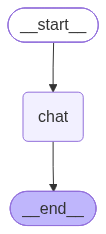

In [44]:
builder=StateGraph(chat_state)
builder.add_node("chat",chat_node)

builder.add_edge(START,"chat")
builder.add_edge("chat",END)
checkpointer=MemorySaver()
graph=builder.compile(checkpointer=checkpointer)
graph


In [45]:
config={"configurable":{"thread_id":"1234"}}
initial_input={
    "messages":[
        ("user","what is ai")
    ]
}
result=graph.invoke(initial_input,config=config)


In [46]:
result

{'messages': [HumanMessage(content='what is ai', additional_kwargs={}, response_metadata={}, id='dd760a4f-72a7-4e58-a4c5-f8324e9d518d')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'model is about to answer a human question', 'question': 'what is ai', 'instruction': 'Do you approve this message?'}, id='2893edeb57e414865a76d4ceef36ccb4')]}

In [47]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'model is about to answer a human question',
 'question': 'what is ai',
 'instruction': 'Do you approve this message?'}

In [ ]:
user_input=input("message {message} do you approve (yes/no)")

In [49]:
final_result=graph.invoke(
    Command(resume={"approved":user_input}),config=config
)
print(final_result["messages"][-1].content)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[{'type': 'text', 'text': 'At its simplest, **AI (Artificial Intelligence)** refers to computer systems designed to mimic human intelligence to perform tasks, solve problems, and learn. \n\nUnlike traditional computer programs that only follow strict, pre-written rules, AI systems can process vast amounts of data, recognize patterns, make decisions, and even improve themselves over time based on new information.\n\nHere is a breakdown to help you understand AI better:\n\n---\n\n### 1. How Does AI Work?\nAt the core of AI are algorithms (sets of instructions) combined with massive amounts of data. Most modern AI relies on two main concepts:\n* **Machine Learning (ML):** Instead of explicitly programming a computer to do a task, developers feed the computer data and let the algorithm "learn" the patterns on its own. (For example, showing a computer millions of pictures of cats until it learns to recognize a cat on its own).\n* **Deep Learning:** A more advanced subset of machine learning